In [16]:
#IMPORTS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.decomposition import FastICA
from sklearn.cluster import DBSCAN

import umap
import pacmap
import hdbscan
from sklearn.metrics import silhouette_score
from matplotlib.patches import Circle

#LOADING DATA
digits = fetch_california_housing()
X = digits.data  # Feature matrix
y = digits.target  # Labels

In [17]:
# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [18]:
#Dimensionality Reduction
X_pca = PCA(n_components=2, random_state=42).fit_transform(X_scaled)
X_tsne = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(X_scaled)
X_umap = umap.UMAP(n_components=2, random_state=42).fit_transform(X_scaled)
X_pacmap = pacmap.PaCMAP(n_components=2, random_state=42).fit_transform(X_scaled)
X_ica = FastICA(n_components=2, random_state=42).fit_transform(X_scaled)

c:\Users\sarah\anaconda3\envs\myenv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [21]:
def plot_grid_all_methods(X_pca, X_tsne, X_umap, X_pacmap, X_ica, eps_values):

    embeddings = [X_pca, X_tsne, X_umap, X_pacmap, X_ica]
    titles = ["PCA", "t-SNE", "UMAP", "PaCMAP", "ICA"]

    fig, axes = plt.subplots(len(eps_values), 5, figsize=(18, 15))

    for row, eps in enumerate(eps_values):
        for col, (emb, title) in enumerate(zip(embeddings, titles)):

            dbscan = DBSCAN(eps=eps, min_samples=5)
            labels = dbscan.fit_predict(emb)

            ax = axes[row, col]
            ax.scatter(emb[:, 0], emb[:, 1], c=labels, cmap="viridis", s=5)

            # Column titles (only top row)
            if row == 0:
                ax.set_title(title)

            # Row labels (eps values)
            if col == 0:
                ax.set_ylabel(f"eps={eps}")

            ax.set_xticks([])
            ax.set_yticks([])

    plt.suptitle("DBSCAN Across DR Methods and eps Values", fontsize=16)
    plt.tight_layout()
    plt.show()

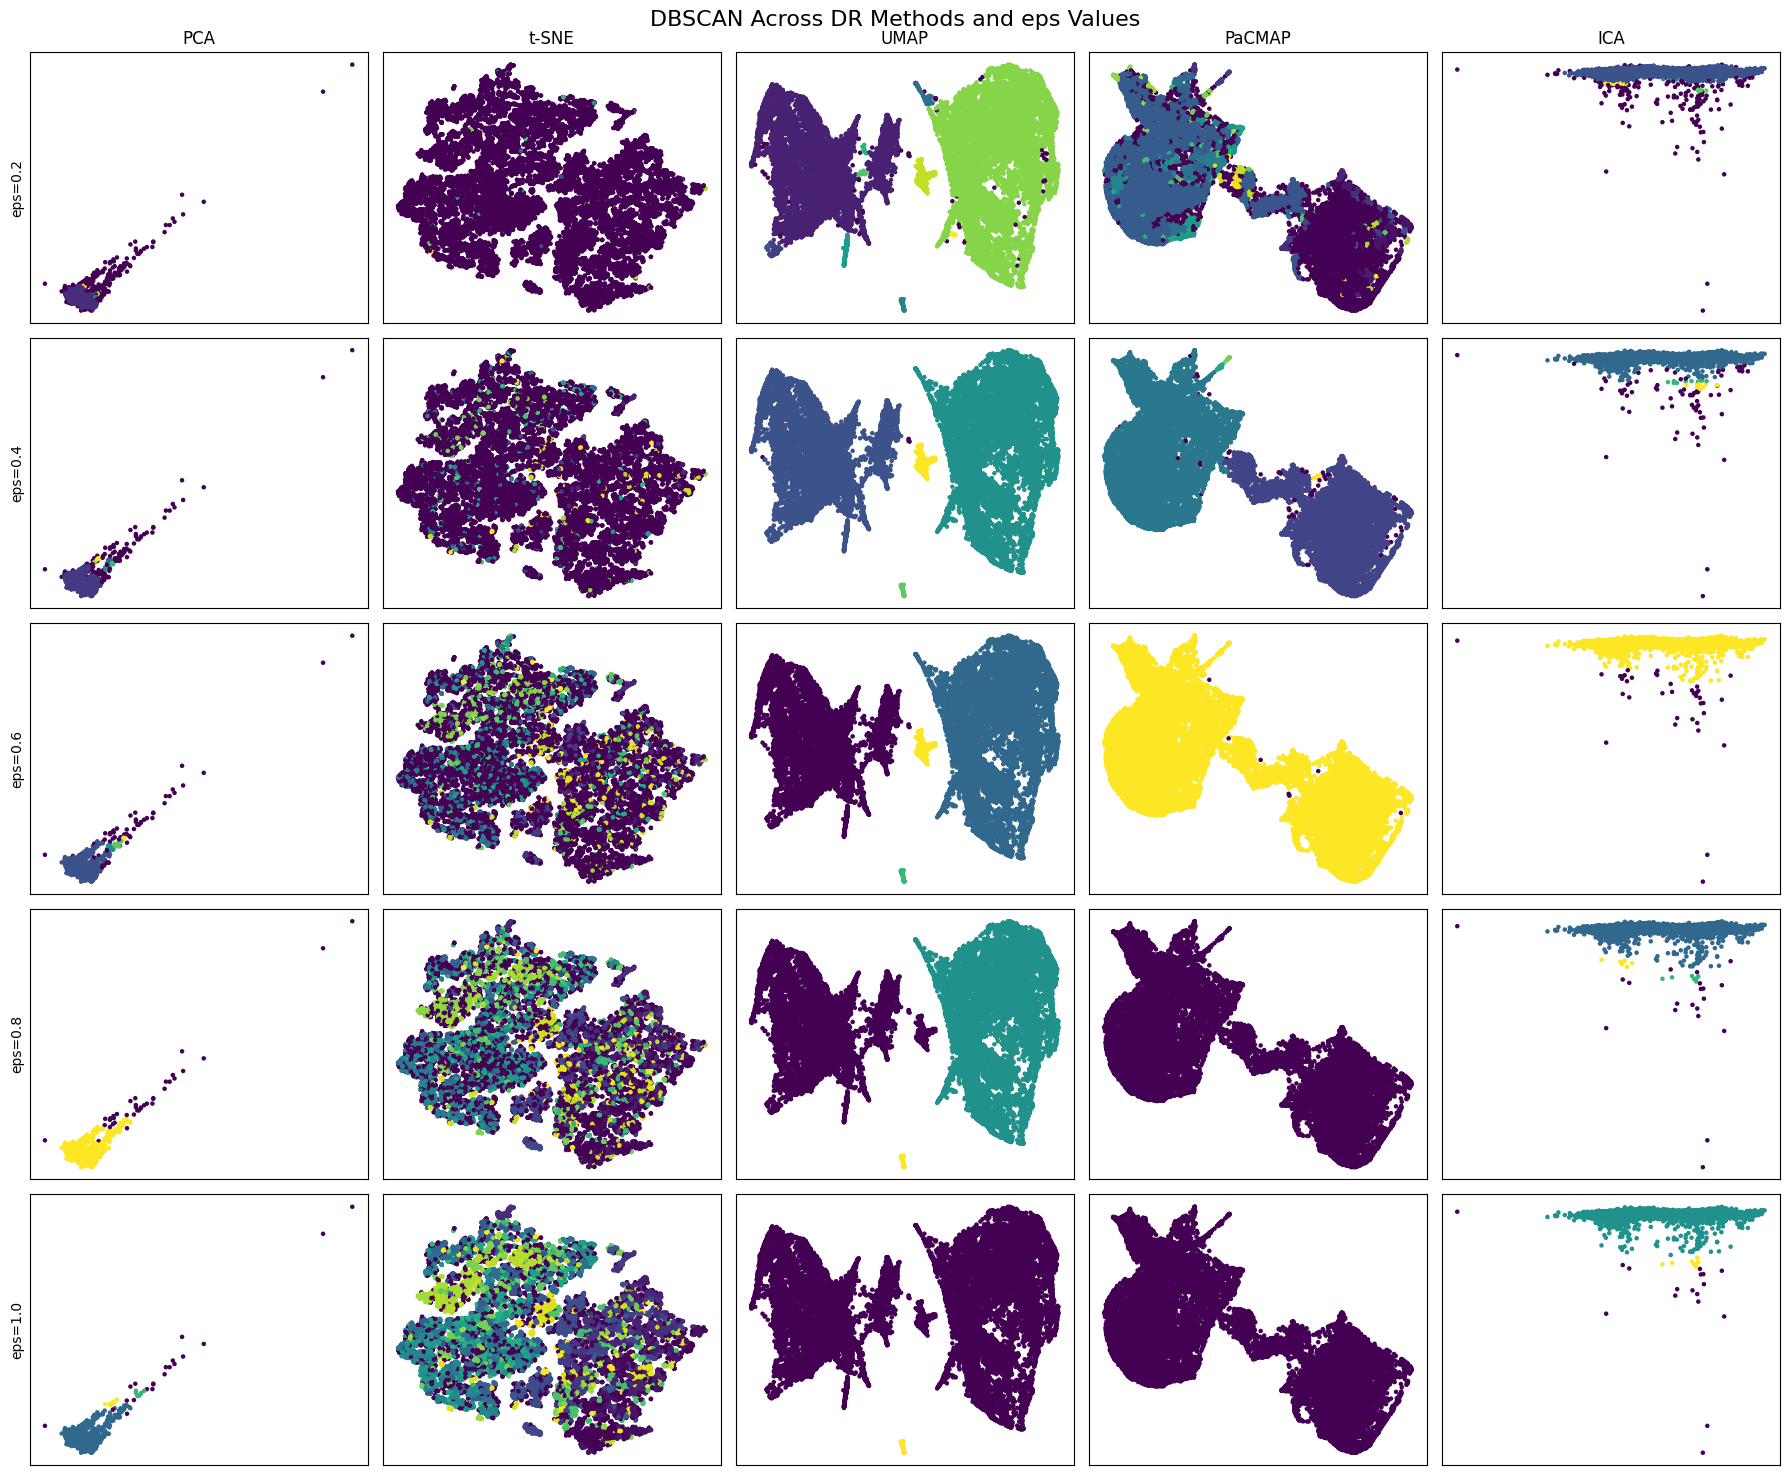

In [22]:
eps_values = [0.2, 0.4, 0.6, 0.8, 1.0]

plot_grid_all_methods(X_pca, X_tsne, X_umap, X_pacmap, X_ica, eps_values)
